# SHM catch in the act (CLL/MBL)

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(fs)
library(stringr)
library(viridis)
library(ggpubr)
library(ggplot2)
#library(Biostrings)
library(Seurat)
library(data.table)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.1     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite

Attaching SeuratObject


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object 

In [2]:
suppressMessages(source("code/functions.R"))

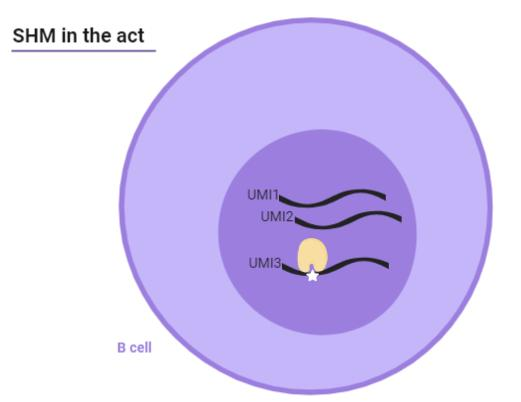

In [3]:
display_png(file="figs/shm-aid.jpeg")  

#### NOTES
- cellranger produces 2 bams in the final output
1. Contigs aligned against consensus 
2. Reads aligmed against contigs

### Load input data (raw data)

In [4]:
df_seq <- Sys.glob("input/output_shm_v4up/MBL/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
      filter(ref_vdj_coverage == '1.0')
  })

In [5]:
head(df_seq)

cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACCTGCATGACATC,ACCACAGTTG,102,1.0,1.0,GGACCTCCTGTGCAAGAACATGAAGCACCTGTGGTTTTTCCTCCTGCTGGTGGCAGCTCCCAGATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGGAGACCCTGTCCCTCATTTGCGCTGTCTCTGGTTACTCCATCAGCAGTGGTTACAACTGGGGCTGGATCCGGCAGCCCCCAGGGAAGGGGCTGGAGTGGATTGGGAGTATCTCTCATAGTGGGAGCACCTACTACAACCCGTCCCTCAAGAGTCGAGTCACCATATCAGTAGACACGTCCAAGAACCAATTCTCCCTGAAGCTGAGGTCTGTGACCGCCGCAGACACGGCCGTGTATTACTGTGCGAGAGAACCTGGAGATAGTCCCCCTAACTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAAGTCCCCGTCGGATACGAGCA,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGGACCTCCTGTGCAAGAACATGAAGCACCTGTGGTTTTTCCTCCTGCTGGTGGCAGCTCCCAGATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGGAGACCCTGTCCCTCATTTGCGCTGTCTCTGGTTACTCCATCAGCAGTGGTTACAACTGGGGCTGGATCCGGCAGCCCCCAGGGAAGGGGCTGGAGTGGATTGGGAGTATCTCTCATAGTGGGAGCACCTACTACAACCCGTCCCTCAAGAGTCGAGTCACCATATCAGTAGACACGTCCAAGAACCAATTCTCCCTGAAGCTGAGGTCTGTGACCGCCGCAGACACGGCCGTGTATTACTGTGCGAGAGAACCTGGAGATAGTCCCCCTAACTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAAGTCCCCGTCGGATACGAGCANNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;14;14;68;68;68;68;68;68;68;68;68;68;68;69;71;71;71;72;72;72;72;72;72;72;72;72;72;72;72;72;72;72;72;72;72;73;73;73;73;73;73;73;73;73;75;75;76;76;78;78;78;78;78;77;78;78;77;77;76;76;76;75;75;75;75;77;77;77;77;75;75;75;75;75;73;73;74;74;74;74;74;74;74;74;73;73;73;72;73;72;72;72;72;72;71;68;67;67;68;67;64;63;63;63;61;60;21;21;22;22;22;22;21;21;21;21;21;21;21;21;21;19;19;19;19;20;20;20;20;20;21;21;21;21;21;21;24;24;24;24;24;24;24;24;24;24;24;25;25;25;25;25;25;25;24;22;22;22;21;21;21;22;22;22;22;22;22;22;22;22;23;23;23;23;23;23;22;22;22;22;22;22;22;22;22;20;20;19;19;17;17;17;17;17;17;16;16;16;16;16;16;17;17;17;17;17;15;15;15;15;15;15;15;15;15;15;15;14;14;14;14;14;14;14;14;14;14;14;14;13;13;13;13;12;12;12;12;12;12;11;11;11;11;11;11;11;11;11;10;9;9;9;9;9;10;10;10;10;10;10;10;10;10;10;10;10;9;9;9;9;9;8;8;8;9;9;9;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;7;6;6;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0,Q1_S5714-HC
AAACCTGCATGACATC,AGCCTCTTGC,197,1.0,1.0,GGCTTTCTGAGAGTCATGGACCTCCTGTGCAAGAACATGAAGCACCTGTGGTTTTTCCTCCTGCTGGTGGCAGCTCCCAGATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGGAGACCCTGTCCCTCATTTGCGCTGTCTCTGGTTACTCCATCAGCAGTGGTTACAACTGGGGCTGGATCCGGCAGCCCCCAGGGAAGGGGCTGGAGTGGATTGGGAGTATCTCTCATAGTGGGAGCACCTACTACAACCCGTCCCTCAAGAGTCGAGTCACCATATCAGTAGACACGTCCAAGAACCAATTCTCCCTGAAGCTGAGGTCTGTGACCGCCGCAGACACGGCCGTGTATTACTGTGCGAGAGAACCTGGAGATAGTCCCCCTAACTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAATTCCCCGTCGGATACGA,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGGCTTTCTGAGAGTCATGGACCTCCTGTGCAAGAACATGAAGCACCTGTGGTTTTTCCTCCTGCTGGTGGCAGCTCCCAGATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGGAGACCCTGTCCCTCATTTGCGCTGTCTCTGGTTACTCCATCAGCAGTGGTTACAACTGGGGCTGGATCCGGCAGCCCCCAGGGAAGGGGCTGGAGTGGATTGGGAGTATCTCTCATAGTGGGAGCACCTACTACAACCCGTCCCTCAAGAGTCGAGTCACCATATCAGTAGACACGTCCAAGAACCAATTCTCCCTGAAGCTGAGGTCTGTGACCGCCGCAGACACGGCCGTGTATTACTGTGCGAGAGAACCTGGAGATAGTCCCCCTAACTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAATTCCCCGTCGGATACGANNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;21;121;121;121;123;123;123;125;125;126;126;127;127;127;128;128;129;129;129;130;131;131;131;131;131;131;131;131;131;131;132;132;132;134;135;136;138;137;137;137;136;136;135;136;136;137;138;138;139;139;139;139;139;139;138

In [6]:
#read doublet table
doublet <- read.csv("output/doublet_in_CLL_MBL.csv")

In [7]:
# positive doublet table

doublet_pos <- doublet %>% filter(scDblFinder.class == "doublet")
head(doublet_pos)

,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,AAACCTGTCACATACG,Q1,doublet,0.8105536,1102,492
2,AAACGGGAGCCTTGAT,Q1,doublet,0.9995284,4055,1181
3,AAAGCAAAGACAGAGA,Q1,doublet,0.3159946,1182,445
4,AAAGCAACACCTTGTC,Q1,doublet,0.9176977,2305,905
5,AAAGTAGGTTAAGATG,Q1,doublet,0.9683905,2939,965
6,AACACGTTCTTAGAGC,Q1,doublet,0.9504855,4390,1207


In [8]:
# number of doublet
table(doublet_pos$scDblFinder.class)


doublet 
    825 

### Add subject information

In [9]:
# load clustaer information df and select subject and cluster 
subject_def <- read.csv("input/cell_source_subject.vireo_hla.20200409.tsv", sep="") 
id <- subject_def %>%
      mutate(vireoCluster=str_replace(vireoCluster, ":", "_")) %>%
      select(subject, vireoCluster) %>%
      unique() %>%
      na.exclude

In [10]:
ss <- readxl::read_excel("input/MBL_CLL_10X.sample_sheet.xlsx") 

In [11]:
samples <- ss %>% left_join(id, by="subject") %>% mutate(name=subject) %>% mutate(subject=paste0(subject,"_",type))
samples

name_subject <- samples %>% select(subject,vireoCluster)

subject,sample,status,gender,source,family,type,vireoCluster,name
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S5001_Donor,31382,DON,F,Q1B,F52,Donor,Q1_fm1,S5001
S10007_Donor,63228,DON,F,Q1B,F66,Donor,Q1_fm2,S10007
S5048_Donor,31920,DON,M,Q1B,F62,Donor,Q1_mm4,S5048
S5714_CLL,23452,PAT,M,Q1B,F63,CLL,Q1_mm5,S5714
S7482_CLL,41156,PAT,F,Q1B,F55,CLL,Q1_fm3,S7482
S9121_MBL,53227,MBL,M,Q1B,.,MBL,Q1_mx6,S9121
S4725_CLL,19456,PAT,M,Q2B,F52,CLL,Q2_fm1,S4725
S9856_CLL,63231,PAT,M,Q2B,F66,CLL,Q2_fm2,S9856
S356_CLL,19430,PAT,M,Q2B,F62,CLL,Q2_mm4,S356


### Define number of total cells

In [12]:
unique(subject_def$subject)

[1] "S5001"  "S10007" NA       "S5048"  "S5714"  "S9121"  "S7482"  "S9856" 
 [9] "S5530"  "S356"   "S7580"  "S9534"  "S4725"

In [13]:
total_cell <- subject_def %>%
           group_by(subject) %>%
           count(subject) %>%
           rename(name=subject) %>%
            dplyr::rename(total_cell=n) %>%
           left_join(samples %>% select(name,subject),by="name")

total_cell
sum(total_cell$total_cell)

name,total_cell,subject
<chr>,<int>,<chr>
S10007,1042,S10007_Donor
S356,1031,S356_CLL
S4725,1115,S4725_CLL
S5001,1134,S5001_Donor
S5048,1437,S5048_Donor
S5530,1067,S5530_Donor
S5714,1069,S5714_CLL
S7482,661,S7482_CLL
S7580,940,S7580_Donor


[1] 16533

In [14]:
# From Diego analysis
cell_by_chain <- read.csv("input/cell_by_chain.csv")

In [18]:
get_n_events <- function(df) {
  nrow(df %>% dplyr::count(subject, cell, position))
}

get_n_cells <- function(df) {  # we should use case because sometimes there are events in HC and LC of a same cell
  nrow(df %>% mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   dplyr::count(case, cell))
}

cll_samples <- c("Q1_S356-HC","Q1_S356-LC","Q1_S5714-HC","Q1_S5714-LC","Q1_S7482-HC","Q1_S7482-LC",
                 "Q2_S4725-HC","Q2_S4725-LC","Q2_S9856-HC","Q2_S9856-LC")

# load data
df <- Sys.glob("input/shm_incl_po_subrg.20210912/CLLMBL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x)) %>% filter(subject %in% cll_samples)
  })

#save df without modification
dfo<- df

stats <- data.frame(step = c("Unfiltered"), n = c(get_n_events(df)), cell=c(get_n_cells(df)))


# f1. filter by doublet

## Include a variable expriment to can filter with the doublet table
df <- df %>% mutate(experiment = str_sub(subject, 1, 2))

df <- df %>% anti_join(doublet_pos, 
            by=c('cell','experiment'))

# filter values
c.region <- c("V","D","J")
c.min_depth <- 5
c.min_umis <- 10
c.min_2nd_ratio <- 0.2
c.max_cells_with_same_variation <- 1


stats <- stats %>%
  add_row(step = "After F1", n = get_n_events(df), cell=c(get_n_cells(df)))

In [19]:
# f2. primary filters (region)
df <- df %>%
  dplyr::filter(region %in% c.region, productive == TRUE, depth >= c.min_depth, ) %>%
  dplyr::group_by(subject, cell, position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F2", n = get_n_events(df), cell=c(get_n_cells(df)))

In [20]:
# f2.5 remove UMIs with "unique" profiles across the cell

unique_umi_max_freq <- 1  # max number of UMIs associated with a profile to be considered unique
unique_umis <- df %>%
  mutate(event = paste0(position, ":", nucl)) %>%
  group_by(experiment, cell, umi) %>%
  summarise(profile = paste(event, collapse = ",")) %>%
  group_by(experiment, cell, profile) %>%
  mutate(n_times = n_distinct(umi)) %>%
  filter(n_times <= unique_umi_max_freq) %>%
  select(experiment, cell, umi)

df <- df %>% anti_join(
  unique_umis,
  by = c("cell", "experiment", "umi")
)

stats <- stats %>%
  add_row(step = "After F2.5", n = get_n_events(df), cell = c(get_n_cells(df)))

`summarise()` has grouped output by 'experiment', 'cell'. You can override using the `.groups` argument.
Adding missing grouping variables: `profile`


In [21]:

# f3. min_umis filter
min_umi_filter <- df %>%
  dplyr::count(subject, cell, position, nucl) %>%
  dplyr::filter(n >= c.min_umis) %>%
  dplyr::select(-n)

df <- df %>%
  dplyr::right_join(
    min_umi_filter,
    by = c("subject", "cell", "position", "nucl")
  ) %>%
  dplyr::group_by(subject, cell, vgene_position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F3", n = get_n_events(df), cell=c(get_n_cells(df)))

In [22]:
# # f3. keep only the biggest two alts
# two_alts_filter <- df %>%
#   dplyr::group_by(subject, cell, position, nucl) %>%
#   summarize(n = n()) %>%
#    dplyr::slice_max(n, n = 2)%>%
#   dplyr::select(subject, cell, position, nucl)

# df <- df %>%
#   dplyr::right_join(two_alts_filter, by = c("subject", "cell", "position", "nucl"))

# stats <- stats %>%
#   add_row(step = "After F2", n = get_n_events(df), cell=c(get_n_cells(df)))

In [23]:
# f4. min_ratio filter
min_ratio_filter <- df %>%
  dplyr::count(subject, cell, position, nucl) %>%
  dplyr::group_by(subject, cell, position) %>%
  dplyr::mutate(ratio = n / sum(n)) %>%
  dplyr::arrange(subject, cell, position, desc(ratio)) %>%
  dplyr::slice(2) %>%
  dplyr::filter(ratio >= c.min_2nd_ratio) %>%
  dplyr::select(subject, cell, position)

df <- df %>%
  dplyr::right_join(
    min_ratio_filter,
    by = c("subject", "cell", "position")
  ) %>%
  dplyr::group_by(subject, cell, vgene_position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F4", n = get_n_events(df), cell=c(get_n_cells(df)))

In [24]:
# summarize
df_productive <- df %>%
  dplyr::select(subject, cell, vgene_position_aligned, productive,subregion) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell, vgene_position_aligned,subregion) %>%
  dplyr::summarise(productive = paste(productive, collapse = "-")) %>%
  dplyr::mutate(productive = ifelse(grepl("-", productive), "MIXED", productive))


df_summary <- df %>%
  dplyr::group_by(subject, cell, vgene_position_aligned, nucl, nucl_po, context_po,subregion) %>%
  dplyr::summarise(umis = n()) %>%
  dplyr::group_by(subject, cell, vgene_position_aligned, nucl_po, context_po,subregion) %>%
  dplyr::arrange(nucl) %>%
  dplyr::summarise(
    variation = paste(nucl, collapse = "-"),
    umis = paste(umis, collapse = "-")
  ) %>%
  dplyr::ungroup() %>%
  left_join(df_productive)

Adding missing grouping variables: `vgene_position`
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned', 'nucl', 'nucl_po', 'context_po'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned', 'nucl_po', 'context_po'. You can override using the `.groups`
argument.
Joining with `by = join_by(subject, cell, vgene_position_aligned, subregion)`


In [25]:
# f5. discard cells with the same mutational profile
cells_same_var_filter <- df_summary %>%
  dplyr::mutate(variation_wpos = paste(vgene_position_aligned, variation, sep=":")) %>%
  dplyr::select(subject, cell, variation_wpos) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell) %>%
  dplyr::summarise(profile=paste0(variation_wpos, collapse = ",")) %>%
  dplyr::group_by(subject, profile) %>%
  dplyr::mutate(cell_same_profile=n_distinct(cell)) %>%
  dplyr::filter(cell_same_profile > 1) %>%
  dplyr::select(subject, cell)

df_summary <- df_summary %>%
  dplyr::anti_join(cells_same_var_filter, by = c("subject", "cell")) %>%
  dplyr::arrange(subject, vgene_position_aligned, variation) %>%
  as.data.frame()

stats <- stats %>%
  add_row(step = "After F5", n = nrow(df_summary), cell=c(get_n_cells(df_summary)))

stats

# summary by subject
df_summary_by_subject <- df_summary %>%
  dplyr::count(subject)

`summarise()` has grouped output by 'subject'. You can override using the `.groups` argument.
Adding missing grouping variables: `profile`


step,n,cell
<chr>,<int>,<int>
Unfiltered,27433,3283
After F1,27203,3255
After F2,1444,977
After F2.5,1421,958
After F3,31,13
After F4,0,0
After F5,0,0


In [26]:
stats_cll <- stats %>% mutate(percentage = cell*100/3283)
write.csv(stats_cll, "output/stats_cll.csv", row.names =FALSE)

In [27]:
write.csv(df_summary, "output/df_summary_CLL_MBL_v2.csv",row.names = FALSE)

In [54]:
print("Samples analysed")
unique(dfo$subject)

[1] "Samples analysed"


[1] "Q1_S5714-HC" "Q1_S5714-LC" "Q1_S7482-HC" "Q1_S7482-LC" "Q2_S4725-HC"
[6] "Q2_S4725-LC" "Q2_S9856-HC" "Q2_S9856-LC"

In [56]:
# add case information
df_filter <- df_summary %>% rename(case=subject) %>%
  mutate(name = str_extract(case, "(?<=_)(.+)(?=\\-)")) %>%
  left_join(total_cell %>% select(name,subject), by="name")

In [57]:
df_filter 

case,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,name,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>


## Include AID motifs

In [26]:
# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")),
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

In [27]:
identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [28]:
#df_filter$aid_motif1 <- mapply(identify_aid_patterns, df_filter$variation, df_filter$context)
#df_filter$aid_motif2 <- mapply(identify_aid_patterns, reverse(df_filter$variation), df_filter$context)

## 2. Downstream analysis

### A) How many events by subject?

In [29]:
df_summary_by_subject <- df_filter %>%
  dplyr::count(subject)

df_summary_by_subject

subject,n
<chr>,<int>
S9121_MBL,16


In [30]:
sum(df_summary_by_subject$n)

[1] 16

### B) How many cells have SHMacting by subject? 

In [31]:
c_cell1 <- df_filter %>%
   group_by(name,case,subject) %>%
   summarise(SHMa_cell = n_distinct(cell)) %>%
   mutate(chain = ifelse(grepl("-(LC)", case), "light", "heavy")) %>%
   right_join(cell_by_chain %>% select(subject,chain,n), by = c("name" = "subject",'chain'='chain'),na.replace = FALSE) %>%
   rename(Total_cell=n) %>%
   mutate(Percentage =SHMa_cell * 100 / Total_cell) 
c_cell1

`summarise()` has grouped output by 'name', 'case'. You can override using the `.groups` argument.


name,case,subject,SHMa_cell,chain,Total_cell,Percentage
<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
S9121,Q1_S9121-LC,S9121_MBL,1,light,756,0.1322751
S5714,NA,NA,NA,light,986,NA
S5714,NA,NA,NA,heavy,982,NA
S7482,NA,NA,NA,heavy,360,NA
S7482,NA,NA,NA,light,360,NA
S7482,NA,NA,NA,light,251,NA
S9121,NA,NA,NA,heavy,757,NA
S356,NA,NA,NA,light,902,NA
S356,NA,NA,NA,heavy,904,NA


In [32]:
c_cell <- df_filter %>%
   group_by(name,case,subject) %>%
   summarise(SHMa_cell = n_distinct(cell)) %>%
   right_join(total_cell, by='subject', na.replace = FALSE) %>%
   mutate(Percentage =SHMa_cell * 100 / total_cell)
c_cell

`summarise()` has grouped output by 'name', 'case'. You can override using the `.groups` argument.


name.x,case,subject,SHMa_cell,name.y,total_cell,Percentage
<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
S9121,Q1_S9121-LC,S9121_MBL,1,S9121,932,0.1072961
NA,NA,S10007_Donor,NA,S10007,1042,NA
NA,NA,S356_CLL,NA,S356,1031,NA
NA,NA,S4725_CLL,NA,S4725,1115,NA
NA,NA,S5001_Donor,NA,S5001,1134,NA
NA,NA,S5048_Donor,NA,S5048,1437,NA
NA,NA,S5530_Donor,NA,S5530,1067,NA
NA,NA,S5714_CLL,NA,S5714,1069,NA
NA,NA,S7482_CLL,NA,S7482,661,NA


### C) How many positions have SHMacting by subject?"

In [33]:
c_pos <-df_filter %>%
  group_by(subject) %>%
  summarise(n_pos = n_distinct(vgene_position_aligned))

c_pos

subject,n_pos
<chr>,<int>
S9121_MBL,16


### Master table

In [34]:
summary <- df_summary_by_subject %>% 
          left_join(c_cell, by = "subject") %>%
          left_join(c_pos, by = "subject") %>%
#          left_join(df_filter %>% select(subject,case), by = "subject") %>%
#          mutate(group = ifelse(grepl("-(LC)", case), "light_chain", "heavy_chain")) %>%
          select(case,subject, everything())

write.csv(summary, "output/summary_CLL_MBL.csv",row.names=FALSE)
summary

case,subject,n,name.x,SHMa_cell,name.y,total_cell,Percentage,n_pos
<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<dbl>,<int>
Q1_S9121-LC,S9121_MBL,16,S9121,1,S9121,932,0.1072961,16


In [35]:
df_summary_by_subject

subject,n
<chr>,<int>
S9121_MBL,16


In [36]:
summary <- df_summary_by_subject %>% 
          right_join(c_cell, by = "subject") %>%
          left_join(c_pos, by = "subject") %>%
          mutate(type = ifelse(grepl("-(HC)", case), "HC", "LC")) %>%
 #         mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
         rename(Patient_id=case) %>%
#          select(subject,total_cell,SHMa_cell,Percentage,n,everything()) %>% #Patient_id
          replace(is.na(.), 0)

write.csv(summary, "output/summary_CLL_MBL.csv",row.names=FALSE)
summary

subject,n,name.x,Patient_id,SHMa_cell,name.y,total_cell,Percentage,n_pos,type
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>
S9121_MBL,16,S9121,Q1_S9121-LC,1,S9121,932,0.1072961,16,LC
S10007_Donor,0,0,0,0,S10007,1042,0.0000000,0,LC
S356_CLL,0,0,0,0,S356,1031,0.0000000,0,LC
S4725_CLL,0,0,0,0,S4725,1115,0.0000000,0,LC
S5001_Donor,0,0,0,0,S5001,1134,0.0000000,0,LC
S5048_Donor,0,0,0,0,S5048,1437,0.0000000,0,LC
S5530_Donor,0,0,0,0,S5530,1067,0.0000000,0,LC
S5714_CLL,0,0,0,0,S5714,1069,0.0000000,0,LC
S7482_CLL,0,0,0,0,S7482,661,0.0000000,0,LC


In [37]:
summary <- df_summary_by_subject %>% 
          right_join(c_cell1, by = "subject") %>%
          left_join(c_pos, by = "subject") %>%
          mutate(type = ifelse(grepl("heavy", case), "HC", "LC")) %>%
 #         mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
         rename(Patient_id=case) %>%
#          select(subject,total_cell,SHMa_cell,Percentage,n,everything()) %>% #Patient_id
          replace(is.na(.), 0)

write.csv(summary, "output/summary_CLL_MBL.csv",row.names=FALSE)
summary

subject,n,name,Patient_id,SHMa_cell,chain,Total_cell,Percentage,n_pos,type
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>
S9121_MBL,16,S9121,Q1_S9121-LC,1,light,756,0.1322751,16,LC
0,0,S5714,0,0,light,986,0.0000000,0,LC
0,0,S5714,0,0,heavy,982,0.0000000,0,LC
0,0,S7482,0,0,heavy,360,0.0000000,0,LC
0,0,S7482,0,0,light,360,0.0000000,0,LC
0,0,S7482,0,0,light,251,0.0000000,0,LC
0,0,S9121,0,0,heavy,757,0.0000000,0,LC
0,0,S356,0,0,light,902,0.0000000,0,LC
0,0,S356,0,0,heavy,904,0.0000000,0,LC


In [38]:
total_cell

name,total_cell,subject
<chr>,<int>,<chr>
S10007,1042,S10007_Donor
S356,1031,S356_CLL
S4725,1115,S4725_CLL
S5001,1134,S5001_Donor
S5048,1437,S5048_Donor
S5530,1067,S5530_Donor
S5714,1069,S5714_CLL
S7482,661,S7482_CLL
S7580,940,S7580_Donor


In [39]:
head(dfo)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
AAACCTGCATGACATC,AGCCTCTTGC,36,G,G,NN.GC,1,TRUE,L,NA,NA,-,NA,-,Q1_S5714-HC
AAACCTGCATGACATC,ATTCCGAGCG,36,G,T,AA.GC,96,TRUE,L,NA,NA,-,NA,-,Q1_S5714-HC
AAACCTGCATGACATC,GAAAACCTAC,36,G,G,NN.GC,2,TRUE,L,NA,NA,-,NA,-,Q1_S5714-HC
AAACCTGCATGACATC,TGCACAGCGA,36,G,G,NN.GC,15,TRUE,L,NA,NA,-,NA,-,Q1_S5714-HC
AAATGCCTCGAACGGA,AACTTGCACT,36,G,G,NN.GC,1,TRUE,L,NA,NA,-,NA,-,Q1_S5714-HC
AAATGCCTCGAACGGA,GGGCCAGTCT,36,G,T,NA.GC,56,TRUE,L,NA,NA,-,NA,-,Q1_S5714-HC


In [40]:
dfo %>%
   group_by(subject) %>%
   summarise(SHMa_cell = n_distinct(cell)) 

subject,SHMa_cell
<chr>,<int>
Q1_S5714-HC,611
Q1_S5714-LC,997
Q1_S7482-HC,64
Q1_S7482-LC,596
Q1_S9121-HC,283
Q1_S9121-LC,922
Q2_S356-HC,387
Q2_S356-LC,1022
Q2_S4725-HC,999


### D) Number of event (positions) by cell

In [41]:
#pos by cell
pbc <- df_filter %>% #filter(source == "K2B_S12500_L")
   group_by(subject, cell) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) 
head(pbc)

`summarise()` has grouped output by 'subject'. You can override using the `.groups` argument.


subject,cell,pos_by_cell
<chr>,<chr>,<int>
S9121_MBL,TCGTACCCACTTCGAA,16


## 3. Visualizations

In [42]:
s_theme <- function() {
      t <- theme_classic() + theme(
        legend.position = "none",
        text = element_text(size = 15),
        axis.text.x = element_text(color = "black",size= 7),
        axis.text = element_text(size= 5),
        axis.title = element_text(size = 7), 
        legend.title = element_text(size = 7),legend.text=element_text(size=5),
        strip.text.x = element_text(size = 7),
        strip.background = element_blank(),
        plot.title = element_text(hjust = 0.5, size = 7)
      )
    
      return(t)
}

In [43]:
# prepare df foe new plots
df_filter_vis <- df_filter %>% 
            separate(variation, c("variation1", "variation2"), "-",remove = FALSE) %>%
            separate(umis, c("umis1", "umis2"), "-",remove = FALSE, convert= TRUE)%>%
            mutate(umis2 = umis2 * -1) %>%
            gather('umis1', 'umis2',key='umi_nu',value="umi") %>%
            mutate(nucleotide = if_else(umi_nu == "umis1", variation1,variation2)) %>%
            group_by(name) %>%
            mutate(cell_no = as.integer(factor(cell)))
#            gather('variation1', 'variation2',key='variation_type',value="nucleotide")

### no filter df without f5

In [44]:
# prepare df foe new plots
df_filter_vis_nf5 <- df_summary %>% 
            mutate(name = str_extract(subject, "(?<=_)(.+)(?=\\-)")) %>%
            separate(variation, c("variation1", "variation2"), "-",remove = FALSE) %>%
            separate(umis, c("umis1", "umis2"), "-",remove = FALSE, convert= TRUE)%>%
            mutate(umis2 = umis2 * -1) %>%
            gather('umis1', 'umis2',key='umi_nu',value="umi") %>%
            mutate(nucleotide = if_else(umi_nu == "umis1", variation1,variation2)) %>%
            group_by(name) %>%
            mutate(cell_no = as.integer(factor(cell)))
#            gather('variation1', 'variation2',key='variation_type',value="nucleotide")

## All subjects

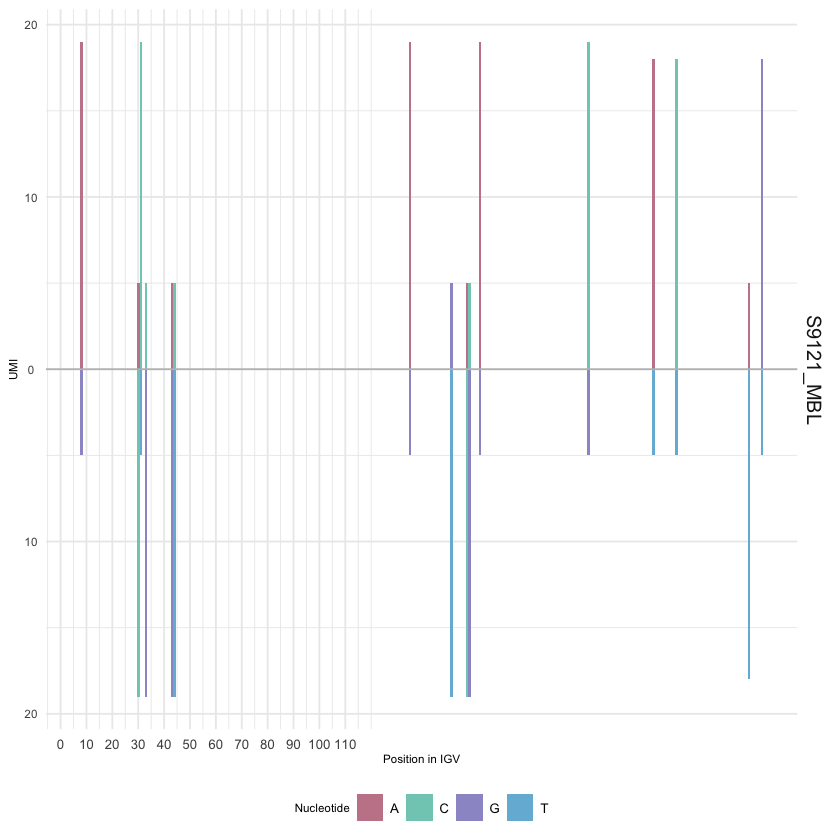

In [45]:
x <- "CLL_MBL"

## calculate breaks values
    breaks_y<- df_filter_vis  %>% pull(umi) %>% pretty()
    breaks_x <- df_filter_vis  %>% pull(vgene_position_aligned) %>% pretty()

pos_plot <- df_filter_vis  %>% 
    ggplot(aes(x =vgene_position_aligned, y = umi, fill = nucleotide))+
  geom_bar(stat = "identity", width=1) +
  scale_x_continuous(name ="Position in IGV",breaks=seq(0,110,10)) +
  scale_y_continuous(name ="UMI",breaks = breaks_y,
                     labels = abs(breaks_y)) +
  theme_minimal() +
  theme(text=element_text(size=7),axis.text.x = element_text(angle = 0, vjust=0.5,size=8),
        axis.text.y = element_text(angle = 0,hjust=0.5,size=7),strip.text.y = element_text(angle=270,size=12),strip.text.x = element_text(angle=0,size=12),legend.position="bottom",legend.text = element_text(size = 8)) +
  labs(fill = "Nucleotide") +
  scale_fill_manual(values=c("#c68699", "#7fccbe", "#9c99cd","#75b9d9")) +
  geom_hline(yintercept=0, color="grey",size=0.5) +
#  geom_text(aes(label=context),nudge_y = 1.4,size =1.7) +
  facet_grid(subject~.)

pos_plot 

fig_save(pos_plot, filename = paste0("figs/CLL_MBL/pos_by_cell_",x), formats = c("pdf", "png"), width = 25, height =10, units = "cm", dpi = 320)

In [46]:
x <- "CLL_MBL"

## calculate breaks values
    breaks_y<- df_filter_vis_nf5  %>% pull(umi) %>% pretty()
    breaks_x <- df_filter_vis  %>% pull(vgene_position_aligned) %>% pretty()

pos_plot <- df_filter_vis_nf5  %>% 
    ggplot(aes(x =vgene_position_aligned, y = umi, fill = nucleotide))+
  geom_bar(stat = "identity", width=1) +
  scale_x_continuous(name ="Position in IGV",breaks=seq(0,110,10)) +
  scale_y_continuous(name ="UMI",breaks = breaks_y,
                     labels = abs(breaks_y)) +
  theme_minimal() +
  theme(text=element_text(size=7),axis.text.x = element_text(angle = 0, vjust=0.5,size=8),
        axis.text.y = element_text(angle = 0,hjust=0.5,size=7),strip.text.y = element_text(angle=270,size=12),strip.text.x = element_text(angle=0,size=12),legend.position="bottom",legend.text = element_text(size = 8)) +
  labs(fill = "Nucleotide") +
  scale_fill_manual(values=c("#c68699", "#7fccbe", "#9c99cd","#75b9d9")) +
  geom_hline(yintercept=0, color="grey",size=0.5) +
  geom_text(aes(label=context),nudge_y = 1.4,size =1.7) +
  facet_grid(subject~.)

pos_plot 

fig_save(pos_plot, filename = paste0("figs/CLL_MBL/pos_by_cell_",x), formats = c("pdf", "png"), width = 25, height =10, units = "cm", dpi = 320)

ERROR while rich displaying an object: Error in FUN(X[[i]], ...): object 'context' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_text.default(obj)
8. paste(capture.output(print

ERROR: Error in FUN(X[[i]], ...): object 'context' not found


### FASTA files generation

### S9121_MBL (LC)

In [ ]:
df_filter

In [ ]:
# df to fasta
cell_to_fasta <- df_seq %>% filter(cell == "TCGTACCCACTTCGAA", subject == 'Q1_S9121-LC') %>% #  cell == "AAACGGGGTATTAGCC"
                 select(umi, aligned_consensus)  #%>% mutate_if(is.character,as.factor)

In [ ]:
Xfasta <- character(nrow(cell_to_fasta) * 2)
Xfasta[c(TRUE, FALSE)] <- paste0(">", cell_to_fasta$umi)
Xfasta[c(FALSE, TRUE)] <- cell_to_fasta$aligned_consensus

In [ ]:
writeLines(Xfasta, "output/S9121_MBL_pos177.8_GAA.fasta")

### S9534_MBL (LC)

In [ ]:
# know the pos
head(dfo %>% filter(cell == "AAGGCAGTCATGCAAC") %>% filter(vgene_position_aligned == 97))

In [ ]:
# df to fasta
cell_to_fasta <- df_seq %>% filter(cell == "AAGGCAGTCATGCAAC", subject == 'Q2_S9534-LC') %>% #  cell == "AAACGGGGTATTAGCC"
                 select(umi, aligned_consensus)  #%>% mutate_if(is.character,as.factor)

In [ ]:
Xfasta <- character(nrow(cell_to_fasta) * 2)
Xfasta[c(TRUE, FALSE)] <- paste0(">", cell_to_fasta$umi)
Xfasta[c(FALSE, TRUE)] <- cell_to_fasta$aligned_consensus

In [ ]:
writeLines(Xfasta, "output/S9534_MBL_pos196.97_AAC.fasta")

## TEST: UMI by event

In [ ]:
head(df)

In [ ]:
c_depth <- df %>%
   group_by(subject,cell) %>%
   count(position)
#   summarise(umi_median = median(depth))

head(c_depth) 

In [ ]:
plot_depth <- function(data) {
            p <- ggplot(data, aes(x=subject, y = n)) +
#        eom_violin() +
        geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.4)) +
        stat_summary(fun.y = median, geom = "point", size =2, color = "black") +
        scale_fill_viridis(discrete = TRUE) +
#        scale_y_continuous(breaks = c(0, 5, 10, 15, 20)) + #25,30,35,40,45
        coord_cartesian(ylim=c(0, 75)) +
#        s_theme() +
        labs(x = "", y = "Amount umi by cell") +
        theme(text = element_text(size = 12), axis.text.x = element_text(angle = 90, vjust=0.5)) #+
#        ggtitle("C) How many UMIs by cell?") 
        return(p)
    }

In [ ]:
options(repr.plot.width = 17, repr.plot.height = 10)
depth_by_sample <- plot_depth(c_depth)
depth_by_sample 
fig_save(depth_by_sample , filename = "figs/depth_by_sample", formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)

In [ ]:
nlevels(c_depth$subject)

In [ ]:
q<-qplot(sample = n, data = c_depth, shape=subject, color=subject) +
   scale_y_continuous(name ="Amount umi by cell",breaks=seq(0, 75, 5), limits= c(0,75))  +
   scale_shape_manual(values=1:14)
q

fig_save(q , filename = "figs/CLL_MBL/qqplot", formats = c("pdf", "png"), width = 25, height = 20, units = "cm", dpi = 320)

## AID expression (categorical) without cells with possibles events

In [ ]:
# read ever experiment
Q1 <- Read10X( data.dir = paste0( "~/repositories/mbl_10x/110_CellRanger_analysis.freeze01/Q2/GEX/outs/raw_feature_bc_matrix/" ) ) %>% 
           CreateSeuratObject( project = "Q1", min.cells = 1, min.features = 200 ) 

Q2 <- Read10X( data.dir = paste0( "~/repositories/mbl_10x/110_CellRanger_analysis.freeze01/Q2/GEX/outs/raw_feature_bc_matrix/" ) ) %>% 
           CreateSeuratObject( project = "Q2", min.cells = 1, min.features = 200 ) 

In [ ]:
# compbined the 2 experiments
CLLMBL <- merge(Q1, y = c(Q2), add.cell.ids = c("Q1", "Q2"), project = "CLLMBL")
CLLMBL

In [ ]:
dd <- CLLMBL@assays$RNA@counts %>% 
               as.data.frame() %>% 
 #              bind_rows(as.data.frame(FL_GEX[[2]]@assays$RNA@counts)) %>%
               rownames_to_column( var = "gene" ) 

In [ ]:
filter(dd, gene == "AICDA")

In [ ]:
# filter only the GEX for AID
dd <- CLLMBL@assays$RNA@counts %>% 
               as.data.frame() %>% 
 #              bind_rows(as.data.frame(FL_GEX[[2]]@assays$RNA@counts)) %>%
               rownames_to_column( var = "gene" ) %>%
               filter( gene %in% c( 'AICDA' ) ) %>% 
               column_to_rownames( var = "gene" ) %>% 
               t() %>% 
               as.data.frame() %>% 
               rownames_to_column( var = "cell" )

head(dd)

In [ ]:
pd <-   dd   %>%
        mutate(experiment = str_sub(cell, 1, 2)) %>%  #str_extract("/\/$/", cell
        mutate(cell = gsub("^.{3}|.{2}$", "", cell))
head(pd)

In [ ]:
# make categorical the expressio of AID
pd_cat <- pd %>%
          mutate(AID=ifelse(AICDA == 0, "No", "Yes")) 
head(pd_cat)

In [ ]:
# make categorical the expressio of AID
pd_cat <- pd %>%
          mutate(AID=ifelse(AICDA == 0, "No", "Yes")) 
head(pd_cat)

In [ ]:
# false positive cell
# anti join of cell with SHM and then use tha df to filter out from the expression data 
no_shm <- dfo %>% anti_join(df_summary %>% select(subject, cell)) %>%
          mutate(experiment = str_sub(subject, 1, 3))
head(no_shm)

In [ ]:
str(pd_cat)

In [ ]:
# df expresssion remove cell with positive and false positive events
pd_cat_filter <- pd_cat %>%
                 anti_join(dfo %>% mutate(experiment = str_sub(subject, 1, 3)))# %>% select(cell,experiment)))
str(pd_cat_filter)

In [ ]:
pos_shm <- df_summary%>% mutate(experiment = str_sub(subject, 1, 3)) %>% left_join(pd_cat,by=c("cell","experiment")) %>% group_by(subject) %>% unique() #%>% summarize(mean_AID= mean(AICDA)) %>% mutate(group="Positive_SHMa")
head(pos_shm)

In [ ]:
# raw df remove false positive cells and true positive cells
neg_shm <- df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>%  #anti_join(df_filter %>% mutate(experiment = str_sub(subject, 1, 3)),by=c("cell","experiment")) %>%
          anti_join(dfo %>% select(subject,cell)) %>% 
          left_join(pd_cat,by=c("cell","experiment")) #%>% group_by(subject)  #%>% unique() #%>% summarize(mean_AID= mean(AICDA)) %>% mutate(group="Negative_SHMa") %>% 
#         filter(subject %in% pos_shm$subject)
head(neg_shm)

In [ ]:
# calculate percentage
pos_shm_perc <- pos_shm  %>% group_by(subject,AID) %>% summarise(counts = n()) %>% mutate(Percentage= counts * 100 / sum(counts)) %>% mutate(group="pos_shm")
head(pos_shm_perc)

In [ ]:
# calculate percentage
neg_shm_perc <- neg_shm  %>% group_by(subject,AID) %>% summarise(counts = n_distinct(cell)) %>% mutate(Percentage= counts * 100 / sum(counts)) %>% mutate(group="pos_shm") %>% mutate(group="neg_shm") #summarise(counts = n()) #%>% mutate(Percentage= counts * 100 / sum(counts))
head(neg_shm_perc)

In [ ]:
#join df
shm_perc <- pos_shm_perc %>%
            bind_rows(neg_shm_perc)

In [ ]:
# count by cell and add percentage
neg_shm %>% 
   group_by(subject) %>%
   summarise(SHMa_cell = n_distinct(cell)) 
 #count(subject,cell,AID) %>% summarise(n= n()) #%>% mutate(Percentage= counts * 100 / sum(counts))

In [ ]:
shm_wider <- shm_perc %>% 
  pivot_wider(names_from=AID, 
              values_from=c(counts, Percentage)) 

In [ ]:
aid_expression <- ggplot(shm_perc, aes(x = group, y = Percentage, fill = AID)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = c("#d3d3d3", "#da8a60"), name = "AID Expression", guide = guide_legend(reverse=TRUE)) +
#    annotate("text", x = 1.5, y = 107, label = "ns", size = 1.8) +
#    annotate("segment", x = 1.1, xend = 1.9, y = 105, yend = 105, colour = "black") +
    labs(x = "",y="Percentage of cell with AID Expression") +
    theme_classic() +
    theme(legend.position = "bottom",legend.margin=margin(t = -0.5, unit='cm'),
          axis.text = element_text(size= 7, angle=90),
          axis.title = element_text(size = 7), 
          legend.title = element_text(size = 5),legend.text=element_text(size=4),legend.key.size = unit(0.5,"line"),
          strip.text = element_text(size = 5)) +
          facet_wrap(.~subject, ncol = 14)


fig_save(aid_expression, filename = "figs/FL/AID_expression_cat", formats = c("pdf", "png"), width = 25, height = 12, units = "cm", dpi = 320)
aid_expression

In [ ]:
aid_expression <- ggplot(pos_shm_perc, aes(x = subject, y = counts, fill = AID)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = c("#d3d3d3", "#da8a60"), name = "AID Expression", guide = guide_legend(reverse=TRUE)) +
#    annotate("text", x = 1.5, y = 107, label = "ns", size = 1.8) +
#    annotate("segment", x = 1.1, xend = 1.9, y = 105, yend = 105, colour = "black") +
    labs(x = "",y="AID expression") +
    theme_classic() +
    theme(legend.position = "bottom",legend.margin=margin(t = -0.5, unit='cm'),
          axis.text = element_text(size= 5, angle=90),
          axis.title = element_text(size = 7), 
          legend.title = element_text(size = 5),legend.text=element_text(size=4),legend.key.size = unit(0.5,"line"))


fig_save(aid_expression, filename = "figs/FL/AID_expression_cat_perc", formats = c("pdf", "png"), width = 15, height = 10, units = "cm", dpi = 320)
aid_expression